# Yield Curve Module 1: NSS from ECB Parameters -- AAA Government Curve

This notebook pulls live Nelson-Siegel-Svensson parameters from the
ECB Statistical Data Warehouse and reconstructs the euro area government
yield curve from first principles.

The ECB publishes two NSS curves daily:

- **AAA-rated issuers** (`G_N_A`) -- Germany, Netherlands, Finland, Luxembourg.
  The primary reference curve used in monetary policy analysis and this notebook.
  Strips out peripheral credit risk, giving a cleaner picture of the euro area
  term structure.
- **All issuers, all ratings** (`G_N_C`) -- full euro area sovereign universe
  including Italy, Spain, Portugal. Embeds peripheral credit spreads.

The distinction matters for risk work: the EBA prescribes OIS discounting
for IRRBB EVE, not the government curve. The spread between OIS, AAA
government, and all-issuer government is analysed in Notebook 2.

**What we are building:**
- The NSS formula implemented from scratch
- Live ECB parameter fetch via our ECBClient
- Zero rate curve from 1 month to 30 years
- Historical analysis of curve shape and parameter evolution

**Regulation context:**
The ECB publishes these parameters daily under the euro area yield curve
statistics. They are used in ICAAP/ILAAP submissions, IRRBB stress testing
(EBA/GL/2022/14), and as the risk-free benchmark for fund NAV
calculations under AIFMD.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from quant_risk.data.ecb import ECBClient

# display settings
pd.set_option("display.float_format", "{:.6f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
print("imports ok")

imports ok


## 1. The NSS Formula

The Nelson-Siegel-Svensson model describes the zero rate at maturity $T$ as:

$$r(T) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-T/\tau_1}}{T/\tau_1} + \beta_2 \cdot \left(\frac{1 - e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right) + \beta_3 \cdot \left(\frac{1 - e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right)$$

Where:
- $\beta_0$ -- long run level (asymptote as $T \to \infty$)
- $\beta_1$ -- slope (spread between short rate and long run level)
- $\beta_2$ -- first hump, controlled by $\tau_1$
- $\beta_3$ -- second hump, controlled by $\tau_2$ (Svensson extension)

In [3]:
def nss_zero_rate(T, beta0, beta1, beta2, beta3, tau1, tau2):
    """
    Nelson-Siegel-Svensson zero rate at maturity T (in years).

    Parameters
    ----------
    T : float or np.ndarray
        Maturity in years. Must be > 0.
    beta0, beta1, beta2, beta3 : float
        Level, slope, and curvature parameters.
    tau1, tau2 : float
        Decay parameters controlling hump locations.

    Returns
    -------
    float or np.ndarray
        Zero rate in percent.
    """
    T = np.asarray(T, dtype=float)

    # avoid division by zero at T=0
    T = np.where(T < 1e-6, 1e-6, T)

    f1 = (1 - np.exp(-T / tau1)) / (T / tau1)
    f2 = f1 - np.exp(-T / tau1)
    f3 = (1 - np.exp(-T / tau2)) / (T / tau2) - np.exp(-T / tau2)

    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3

# quick sanity check
print(nss_zero_rate(10, 1.178, 0.721, 1.991, 7.699, 0.808, 14.616))

3.088711420392715


In [4]:
client = ECBClient()
params = client.get_nss_parameters(last_n=1) # 1-row df
print(params)

# extract today's parameters as a dict
p = params.iloc[-1] # a dataseries
print(f"\nDate: {params.index[-1]}")
print(f"beta0 = {p.beta0:.4f}\nbeta1 = {p.beta1:.4f}\nbeta2 = {p.beta2:.4f}")
print(f"beta3 = {p.beta3:.4f}\ntau1 = {p.tau1:.4f}\ntau2 = {p.tau2:.4f}")

              beta0    beta1    beta2    beta3     tau1      tau2
2026-04-16 1.205362 0.758321 1.826325 7.615972 0.841758 14.950549

Date: 2026-04-16
beta0 = 1.2054
beta1 = 0.7583
beta2 = 1.8263
beta3 = 7.6160
tau1 = 0.8418
tau2 = 14.9505


## 2. Reconstructing the Full Curve

Curves reconstructed using last ECB parameters, for the full maturity spectrum (1m to 30y):

1. Zero rates $r(T)$
2. Discount factors $P(0,T)$
3. Instantaneous forward rate $f(0,T)$ -- rate for infinitesimal period at $T$
   (options, HJM, term structure models)
4. Discrete forward rate $f(t, t+1)$ -- rate for the period from $t$ to $t+1$
   (bond pricing, swap legs)

### Continuous vs Discrete Forward Rates

Both forward rates answer the same question -- *what rate does the market imply
for a future lending period?* -- but with different compounding assumptions.

**Continuous forward rate** is the instantaneous rate at maturity $T$:

$$f(0,T) = -\frac{d}{dT} \ln P(0,T)$$

Computed numerically here using finite differences on the discount curve.
Used in options pricing, HJM framework, and term structure models where
continuous compounding is the natural convention.

**Discrete forward rate** between maturities $t$ and $t+1$ is the rate that
chains exactly with the zero rates:

$$(1 + r_{t+1})^{t+1} = (1 + r_t)^t \cdot (1 + f_{t \to t+1})$$

Solving for the forward:

$$f_{t \to t+1} = \frac{(1 + r_{t+1})^{t+1}}{(1 + r_t)^t} - 1$$

By construction, plugging this back in reconciles exactly with the next
zero rate -- no numerical approximation error. Used in bond pricing and
swap leg projections where discrete compounding matches contractual
cash flow conventions.

In [13]:
# maturity grid from 1 month to 30 years
maturities = np.linspace(1/12, 30, 360)

# zero rates using today's parameters
zero_rates = nss_zero_rate(
    maturities,
    beta0 = p.beta0,
    beta1 = p.beta1,
    beta2 = p.beta2,
    beta3 = p.beta3,
    tau1  = p.tau1,
    tau2  = p.tau2,
)

# discount factors: P(0,T) = exp(-r(T) * T / 100)
# divide by 100 because rates are in percent
discount_factors = np.exp(-zero_rates / 100 * maturities)

# continuous forward rates: f(0,T) = -d/dT ln P(0,T)
# numerical approximation using finite differences
dT = maturities[1] - maturities[0]
fwd_continuous = -np.diff(np.log(discount_factors)) / dT
fwd_continuous = np.append(fwd_continuous, fwd_continuous[-1]) * 100

# discrete forward rates: f(t, t+1) = (1+r_{t+1})^{t+1} / (1+r_t)^t - 1
# rates divided by 100 for computation, result multiplied back
r = zero_rates / 100
growth = (1 + r) ** maturities
fwd_discrete_step = np.diff(growth) / growth[:-1]
fwd_discrete_step = np.append(fwd_discrete_step, fwd_discrete_step[-1])

# annualise: each step is dT years, so compound up to 1 year
fwd_discrete = ((1 + fwd_discrete_step) ** (1 / dT) - 1) * 100

# collect into a DataFrame
curve = pd.DataFrame({
    "maturity"        : maturities,
    "zero_rate"       : zero_rates,
    "discount_factor" : discount_factors,
    "fwd_continuous"  : fwd_continuous,
    "fwd_discrete"    : fwd_discrete,
})

print(curve.head(10))
print(f"\nshape: {curve.shape}")

   maturity  zero_rate  discount_factor  fwd_continuous  fwd_discrete
0  0.083333   2.033153         0.998307        2.155019      2.155055
1  0.166667   2.094086         0.996516        2.254191      2.254275
2  0.250000   2.147454         0.994646        2.334155      2.334283
3  0.333333   2.194130         0.992713        2.397934      2.398097
4  0.416667   2.234890         0.990731        2.448152      2.448338
5  0.500000   2.270434         0.988712        2.487077      2.487274
6  0.583333   2.301383         0.986665        2.516667      2.516865
7  0.666667   2.328293         0.984598        2.538607      2.538799
8  0.750000   2.351662         0.982517        2.554345      2.554526
9  0.833333   2.371930         0.980428        2.565122      2.565287

shape: (360, 5)


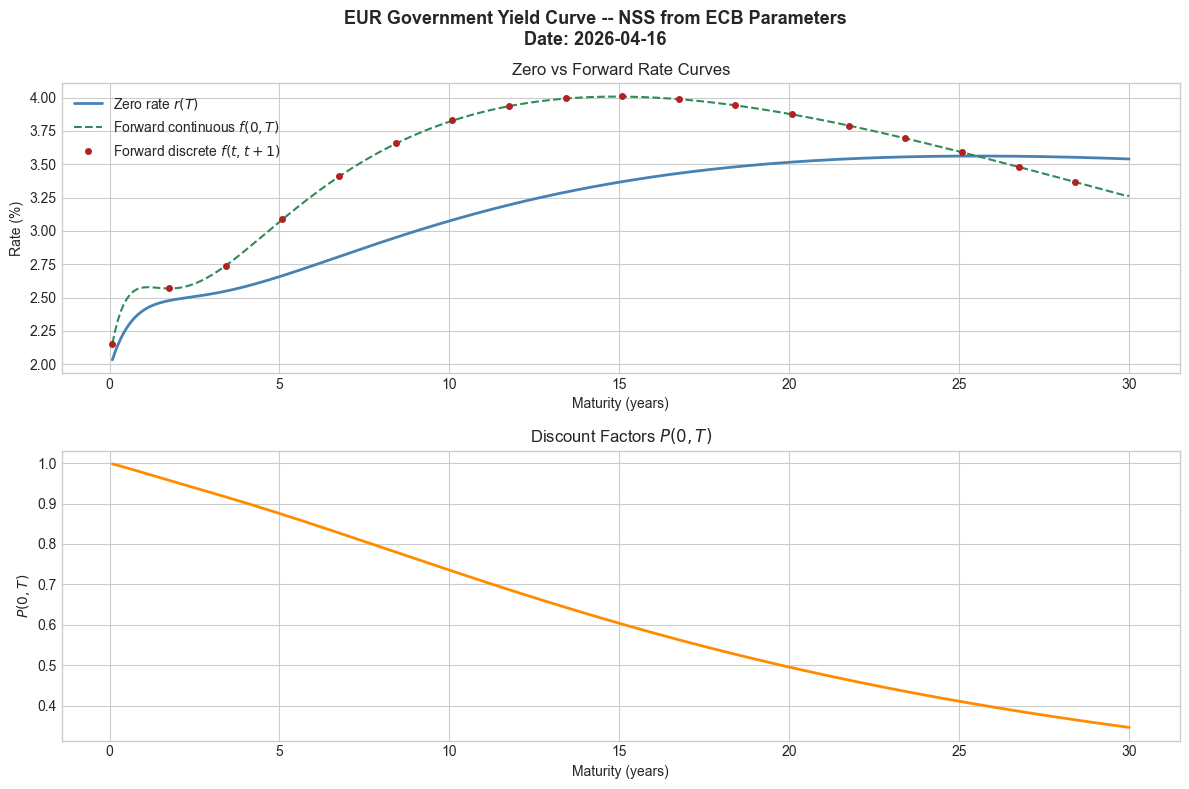

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# zero and both forward rates together
axes[0].plot(
    curve.maturity, curve.zero_rate,
    color="steelblue", linewidth=2, label="Zero rate $r(T)$"
)
axes[0].plot(
    curve.maturity, curve.fwd_continuous,
    color="seagreen", linewidth=1.5,
    linestyle="--", label="Forward continuous $f(0,T)$"
)
axes[0].plot(
    curve.maturity, curve.fwd_discrete,
    color="firebrick", linewidth=0.8,
    marker="o", markevery=20, markersize=4,
    linestyle="none",
    label="Forward discrete $f(t,t+1)$"
)
axes[0].set_title("Zero vs Forward Rate Curves")
axes[0].set_ylabel("Rate (%)")
axes[0].set_xlabel("Maturity (years)")
axes[0].legend()

# discount factors
axes[1].plot(
    curve.maturity, curve.discount_factor,
    color="darkorange", linewidth=2
)
axes[1].set_title("Discount Factors $P(0,T)$")
axes[1].set_ylabel("$P(0,T)$")
axes[1].set_xlabel("Maturity (years)")

fig.suptitle(
    f"EUR Government Yield Curve -- NSS from ECB Parameters\n"
    f"Date: {params.index[-1]}",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Continuous vs Discrete Forward Rates -- Comparison

Both measures are plotted together above. At this grid resolution (monthly steps, $dT \approx 0.083$ years)
the two are visually indistinguishable -- which is the correct result.

The discrete forward rate converges to the continuous one as the interval shrinks:

$$\lim_{\Delta t \to 0} \frac{(1 + r_{t+\Delta t})^{t + \Delta t}}{(1 + r_t)^t} - 1 = f(0,T) \cdot \Delta t$$

The small residual gap visible numerically (not visually) at the short end has two sources:

1. **Finite difference approximation** -- the continuous forward $f(0,T)$ is computed
   as $-\Delta \ln P / \Delta T$, which is an approximation of the true derivative.
   The error is $O(\Delta T)$ -- it shrinks as the grid gets finer.

2. **Compounding convention** -- the discrete rate uses annual compounding
   $(1+r)^T$ while the continuous rate uses exponential compounding $e^{rT}$.
   These diverge slightly even at the same interval size.

In practice the choice between them is driven by the instrument, not by precision:
- Swap floating legs, bond cash flows -- discrete, matching contractual conventions
- Options, HJM simulations, XVA -- continuous, matching the mathematical framework

In [16]:
diff = curve.fwd_discrete - curve.fwd_continuous
print(f"Max difference:  {diff.abs().max():.6f}%")
print(f"Mean difference: {diff.abs().mean():.6f}%")
print(f"At 1Y:  discrete={curve.fwd_discrete[12]:.4f}%  continuous={curve.fwd_continuous[12]:.4f}%")
print(f"At 10Y: discrete={curve.fwd_discrete[120]:.4f}%  continuous={curve.fwd_continuous[120]:.4f}%")

Max difference:  0.002698%
Mean difference: 0.001046%
At 1Y:  discrete=2.5776%  continuous=2.5775%
At 10Y: discrete=3.8284%  continuous=3.8258%


## 3. Key Rate Table

Standard maturities used in ICAAP/IRRBB reporting and fund risk dashboards.
This is the format a risk committee would see with the **pillar rates** that matter for bucketed sensitivity analysis.

Under EBA IRRBB guidelines (EBA/GL/2022/14) these pillar maturities are the
basis for EVE and NII shock calculations.

## 4. DV01 -- Dollar Value of a Basis Point

DV01 measures the price sensitivity of a position to a 1 basis point (0.01%)
move in interest rates. It is the most common risk metric on fixed income desks
and the building block for IRRBB EVE calculations.

**Derivation for a zero coupon bond**

The price of a zero coupon bond with notional $N$ and maturity $T$ is:

$$Price = N \cdot P(0,T) = N \cdot e^{-r(T) \cdot T / 100}$$

Taking the derivative with respect to the zero rate $r$ (quoted in percent):

$$\frac{dPrice}{dr} = -\frac{T}{100} \cdot N \cdot P(0,T)$$

DV01 is the price change for a 1 basis point = 0.01% move in $r$:

$$DV01 = -\frac{dPrice}{dr} \cdot 0.01 = \frac{T \cdot N \cdot P(0,T)}{10{,}000}$$

For $N = 1{,}000{,}000$:

$$DV01 = T \cdot P(0,T) \cdot 100$$

**Modified Duration**

Modified duration normalises DV01 by the bond price, giving the percentage
price change per 1 unit move in yield $y$ expressed in decimal:

$$ModDur = -\frac{1}{Price} \cdot \frac{dPrice}{dy}$$

For a zero coupon bond, substituting $Price = N \cdot e^{-y \cdot T}$:

$$\frac{dPrice}{dy} = -T \cdot N \cdot e^{-y \cdot T} = -T \cdot Price$$

Therefore:

$$ModDur = T$$

For a zero coupon bond, modified duration equals maturity exactly -- the most
elegant result in fixed income. The relationship between DV01 and modified
duration is:

$$DV01 = ModDur \cdot Price \cdot 0.0001$$

For a coupon bond, modified duration is the present-value weighted average
maturity of all cash flows:

$$ModDur = \frac{\sum_i T_i \cdot C_i \cdot P(0, T_i)}{Price}$$

Always less than final maturity because coupon payments arrive before principal,
pulling the weighted average earlier.

**Key observations from the table**

- DV01 increases with maturity -- longer bonds are more rate sensitive
- DV01 is dampened by the discount factor -- a 30Y bond is not 3x as sensitive
  as a 10Y because $P(0,30) \ll P(0,10)$
- For a zero coupon bond, modified duration equals maturity exactly: $ModDur = T$
- A coupon bond DV01 is the sum of zero coupon DV01s across all its cash flows --
  this is the key rate decomposition used in FRTB and ICAAP

In [18]:
# standard pillar maturities in years
pillars = {
    "3M":  3/12,
    "6M":  6/12,
    "1Y":  1.0,
    "2Y":  2.0,
    "3Y":  3.0,
    "5Y":  5.0,
    "7Y":  7.0,
    "10Y": 10.0,
    "15Y": 15.0,
    "20Y": 20.0,
    "30Y": 30.0,
}

# compute zero rates and discount factors at each pillar
records = []
for label, T in pillars.items():
    r = nss_zero_rate(
        T,
        beta0 = p.beta0,
        beta1 = p.beta1,
        beta2 = p.beta2,
        beta3 = p.beta3,
        tau1  = p.tau1,
        tau2  = p.tau2,
    )
    df = np.exp(-r / 100 * T)
    records.append({
        "maturity"         : label,
        "years"            : T,
        "zero_rate_%"      : round(r, 4),
        "discount_factor"  : round(df, 6),
        "dv01_per_1M" : round(T * df * 100, 2),
    })

key_rates = pd.DataFrame(records).set_index("maturity")
print(f"EUR Government Key Rates -- {params.index[-1]}\n")
print(key_rates.to_string())

EUR Government Key Rates -- 2026-04-16

             years  zero_rate_%  discount_factor  dv01_per_1M
maturity                                                     
3M        0.250000     2.147500         0.994646    24.870000
6M        0.500000     2.270400         0.988712    49.440000
1Y        1.000000     2.404700         0.976240    97.620000
2Y        2.000000     2.488600         0.951447   190.290000
3Y        3.000000     2.527500         0.926979   278.090000
5Y        5.000000     2.656800         0.875607   437.800000
7Y        7.000000     2.828700         0.820364   574.250000
10Y      10.000000     3.074600         0.735312   735.310000
15Y      15.000000     3.365500         0.603615   905.420000
20Y      20.000000     3.514500         0.495149   990.300000
30Y      30.000000     3.539100         0.345854  1037.560000


In [19]:
key_rates.style\
    .format({
        "years"           : "{:.2f}",
        "zero_rate_%"     : "{:.4f}%",
        "discount_factor" : "{:.6f}",
        "mod_duration"    : "{:.2f}",
        "dv01_per_1M"     : "{:,.2f}",
    })\
    .set_caption(f"EUR Government Key Rates -- {params.index[-1]}")\
    .background_gradient(subset=["dv01_per_1M"], cmap="Blues")

,years,zero_rate_%,discount_factor,dv01_per_1M
maturity,,,,
3M,0.25,2.1475%,0.994646,24.87
6M,0.50,2.2704%,0.988712,49.44
1Y,1.00,2.4047%,0.976240,97.62
2Y,2.00,2.4886%,0.951447,190.29
3Y,3.00,2.5275%,0.926979,278.09
5Y,5.00,2.6568%,0.875607,437.80
7Y,7.00,2.8287%,0.820364,574.25
10Y,10.00,3.0746%,0.735312,735.31
15Y,15.00,3.3655%,0.603615,905.42


## 5. Historical Analysis -- Curve Evolution

Pulling 2 years of NSS parameters to show how the EUR government curve
evolved through the ECB rate hiking cycle (2022-2023) and the subsequent
cutting cycle (2024-2025).

Key parameters to watch:
- $\beta_0$ -- long run level: did the market reprice the neutral rate?
- $\beta_1$ -- slope: when did the curve invert and when did it normalise?
- $\beta_0 + \beta_1$ -- instantaneous short rate implied by the model

In [20]:
# fetch 2 years of daily NSS parameters
params_hist = client.get_nss_parameters(last_n=520)
params_hist.index = pd.to_datetime(params_hist.index)
params_hist = params_hist.sort_index()

print(f"Date range: {params_hist.index[0].date()} to {params_hist.index[-1].date()}")
print(f"Observations: {len(params_hist)}")
print(f"\nFirst row:\n{params_hist.iloc[0]}")
print(f"\nLast row:\n{params_hist.iloc[-1]}")

Date range: 2024-04-02 to 2026-04-16
Observations: 520

First row:
beta0    0.853369
beta1    3.117231
beta2   -2.539239
beta3    5.928586
tau1     2.452239
tau2    11.918371
Name: 2024-04-02 00:00:00, dtype: float64

Last row:
beta0    1.205362
beta1    0.758321
beta2    1.826325
beta3    7.615972
tau1     0.841758
tau2    14.950549
Name: 2026-04-16 00:00:00, dtype: float64


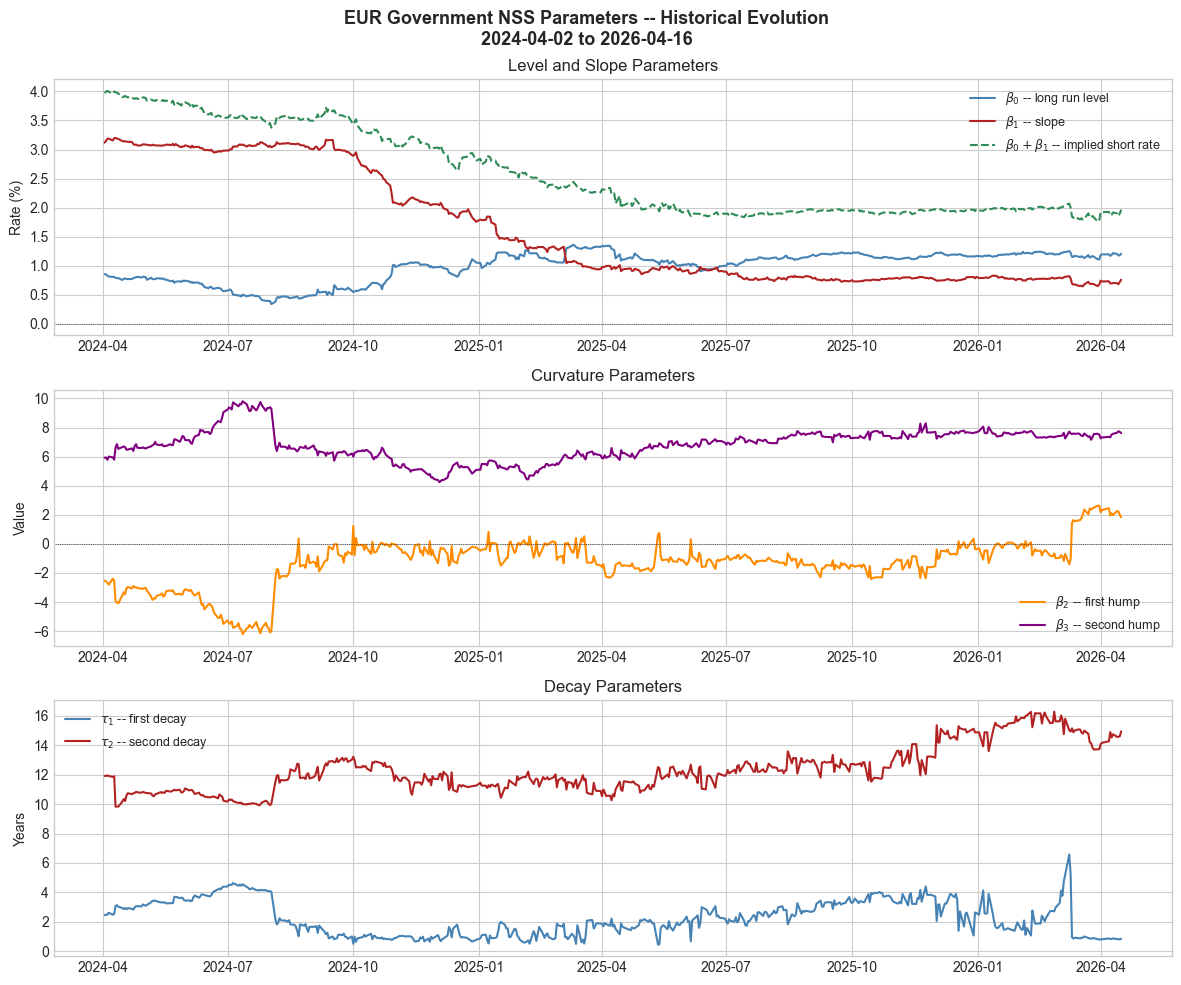

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# beta0 and beta1 -- the most economically meaningful
axes[0].plot(params_hist.index, params_hist.beta0,
             color="steelblue", linewidth=1.5, label="$\\beta_0$ -- long run level")
axes[0].plot(params_hist.index, params_hist.beta1,
             color="firebrick", linewidth=1.5, label="$\\beta_1$ -- slope")
axes[0].plot(params_hist.index, params_hist.beta0 + params_hist.beta1,
             color="seagreen", linewidth=1.5, linestyle="--",
             label="$\\beta_0 + \\beta_1$ -- implied short rate")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle=":")
axes[0].set_title("Level and Slope Parameters")
axes[0].set_ylabel("Rate (%)")
axes[0].legend(fontsize=9)

# beta2 and beta3 -- curvature
axes[1].plot(params_hist.index, params_hist.beta2,
             color="darkorange", linewidth=1.5, label="$\\beta_2$ -- first hump")
axes[1].plot(params_hist.index, params_hist.beta3,
             color="purple", linewidth=1.5, label="$\\beta_3$ -- second hump")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle=":")
axes[1].set_title("Curvature Parameters")
axes[1].set_ylabel("Value")
axes[1].legend(fontsize=9)

# tau1 and tau2 -- decay speeds
axes[2].plot(params_hist.index, params_hist.tau1,
             color="steelblue", linewidth=1.5, label="$\\tau_1$ -- first decay")
axes[2].plot(params_hist.index, params_hist.tau2,
             color="firebrick", linewidth=1.5, label="$\\tau_2$ -- second decay")
axes[2].set_title("Decay Parameters")
axes[2].set_ylabel("Years")
axes[2].legend(fontsize=9)

fig.suptitle(
    "EUR Government NSS Parameters -- Historical Evolution\n"
    f"{params_hist.index[0].date()} to {params_hist.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Interpretation -- EUR Curve Evolution April 2024 to April 2026

### Level and Slope (top panel)

The dominant story is the collapse of $\beta_1$ from 3.1% in April 2024 to 0.7%
by mid-2025, where it stabilises. This is the ECB cutting cycle made visible.

At the start of the sample the implied short rate ($\beta_0 + \beta_1 \approx 4\%$)
was far above the long run level ($\beta_0 \approx 0.85\%$) -- a deeply inverted
curve reflecting peak policy tightening and market expectations of eventual cuts.
The inversion was not a recession signal in the traditional sense but a mechanical
consequence of the ECB having pushed the deposit facility rate to 4% while the
long end remained anchored by structural demand from pension funds and insurers.

The cutting cycle executed through H2 2024 is visible as a sharp, continuous
decline in $\beta_1$ -- the slope compresses as short rates fall faster than long
rates. By early 2025 the curve has largely normalised: $\beta_0 + \beta_1 \approx 2\%$
with $\beta_0 \approx 1.2\%$, implying a terminal rate around 1.2% that the market
considers the long run neutral rate for the euro area. This is broadly consistent
with ECB staff estimates of $r^*$ in the 1.0-1.5% range.

The stability of $\beta_1$ around 0.7% from mid-2025 onward suggests the market
believes the cutting cycle is largely complete and the curve has found its new
equilibrium shape.

### Curvature (middle panel)

$\beta_2$ oscillates around zero throughout the sample, moving from deeply negative
(-6) in mid-2024 to slightly positive by April 2026. Negative $\beta_2$ suppresses
the medium term hump -- consistent with a curve under inversion pressure where the
belly (2-5Y) is being pulled down by rate cut expectations. The drift toward zero
and positive territory reflects the normalisation of medium term expectations as
the cutting cycle concludes.

$\beta_3$ is remarkably stable around 6-8 throughout, with one sharp spike to 10
in mid-2024. This second hump parameter captures the long end shape -- the
persistent structural demand for duration from European institutional investors
keeps this part of the curve well-behaved regardless of short term policy moves.
The spike in mid-2024 coincides with a period of elevated long end volatility
driven by fiscal concerns in France ahead of the snap election.

### Decay Parameters (bottom panel)

$\tau_2$ drifts steadily upward from 10-11 years to 15-16 years through the
sample. A larger $\tau_2$ means the second hump peaks at a longer maturity --
the long end structure is being pushed further out the curve as the short end
normalises. This is consistent with quantitative tightening reducing ECB holdings
of long dated bonds and the market repricing the long end term premium.

$\tau_1$ is more volatile, spiking sharply in early 2026. This reflects
instability in the short end fitting -- when $\beta_1$ is small the first hump
has little economic significance and the optimiser has difficulty pinning $\tau_1$
precisely. This is a known limitation of NSS at low slope environments: parameter
identification weakens when the curve is flat. In practice the ECB applies
constraints to stabilise $\tau_1$ in these conditions.

### Risk Management Implications

The transition from inverted to normal slope has direct IRRBB consequences.
Under EBA parallel shock scenarios (+200bps, -200bps) the EVE impact is
significantly larger on a normal shaped curve than an inverted one because
the long end discount factors are more sensitive when starting from lower rates.
Banks that positioned their banking books for a prolonged inversion through
2024 faced mark-to-market losses as the curve normalised -- precisely the
dynamic the IRRBB framework is designed to capture and stress test.

## 7. Parameter Sensitivity Analysis

Single-parameter shifts around today's ECB calibration, all others held fixed.
Shift sizes are ±1σ and ±2σ computed from the 2024-2026 daily parameter series.

For $\beta$ parameters shifts are applied symmetrically. For $\tau_1$ and $\tau_2$
negative shifts are floored at a minimum value of 0.1 years -- both decay parameters
are strictly positive by construction and unconstrained shifts can produce
negative values that break the model, particularly for $\tau_1$ which today sits
below one historical standard deviation from zero.

In [24]:
stds = params_hist.std()
print(stds.round(4))

beta0   0.258200
beta1   0.968400
beta2   1.633800
beta3   1.063000
tau1    1.160900
tau2    1.551200
dtype: float64


Shifts applied (in parameter units):
  beta0: [np.float64(-0.516), np.float64(-0.258), np.float64(0.258), np.float64(0.516)]
  beta1: [np.float64(-1.937), np.float64(-0.968), np.float64(0.968), np.float64(1.937)]
  beta2: [np.float64(-3.268), np.float64(-1.634), np.float64(1.634), np.float64(3.268)]
  beta3: [np.float64(-2.126), np.float64(-1.063), np.float64(1.063), np.float64(2.126)]
  tau1: [np.float64(-0.742), np.float64(-0.742), np.float64(1.161), np.float64(2.322)]
  tau2: [np.float64(-3.102), np.float64(-1.551), np.float64(1.551), np.float64(3.102)]


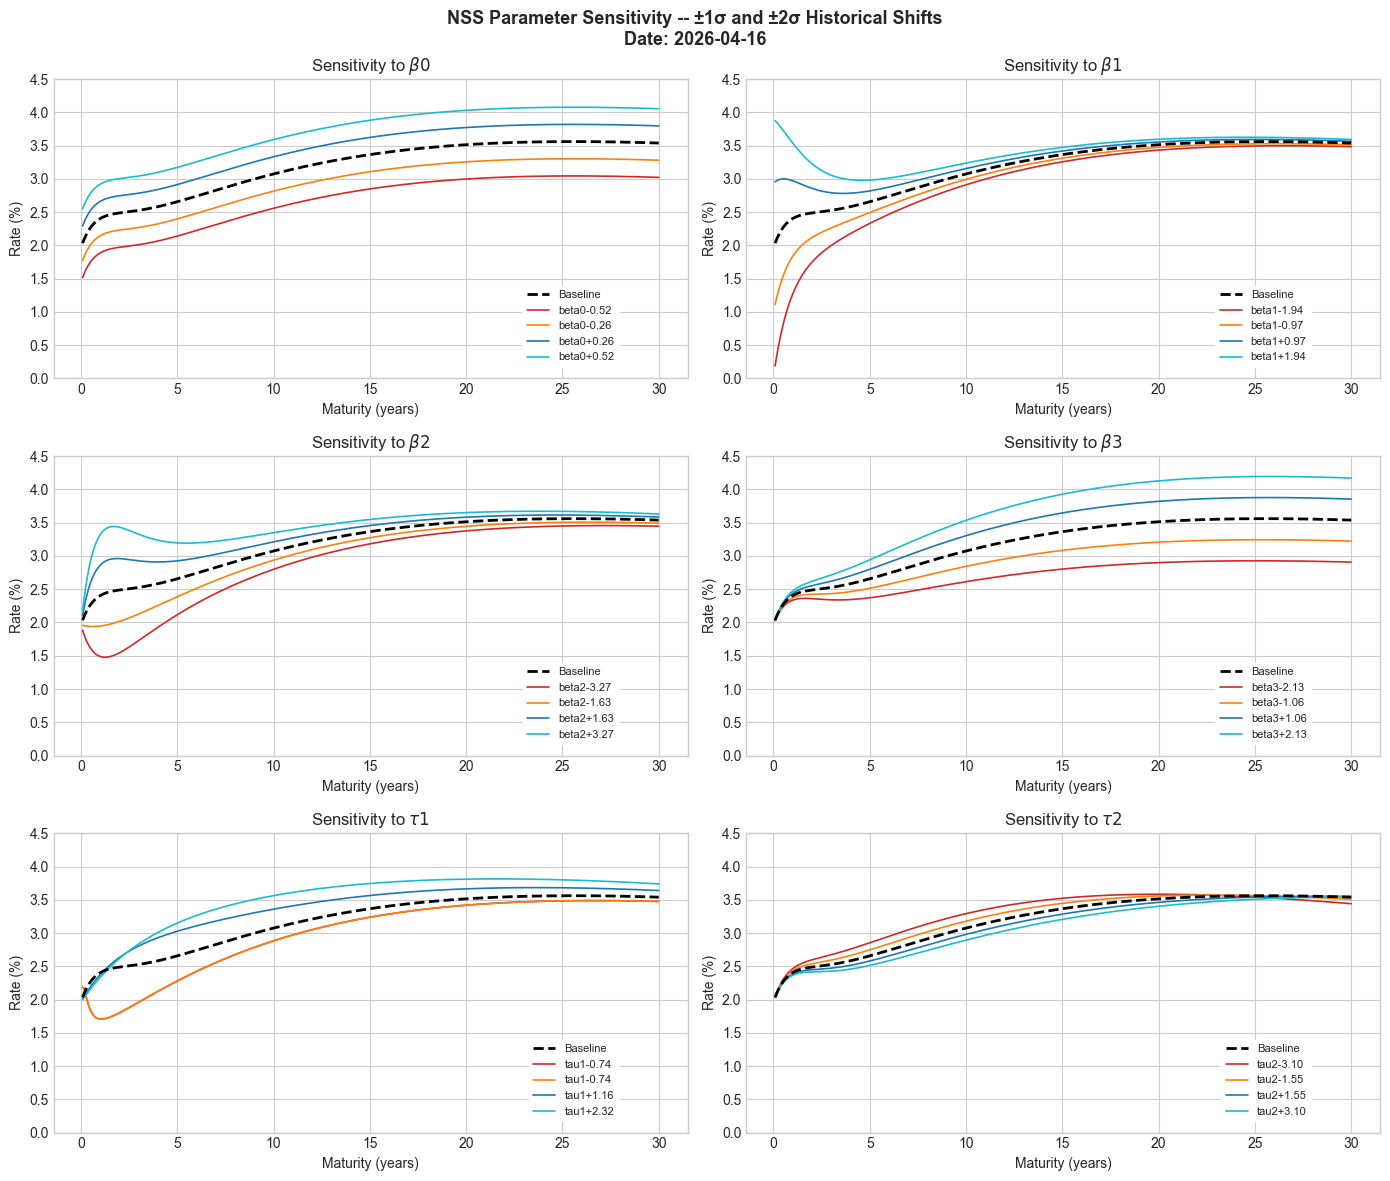

In [43]:
# today's parameters as baseline
base = dict(
    beta0 = p.beta0,
    beta1 = p.beta1,
    beta2 = p.beta2,
    beta3 = p.beta3,
    tau1  = p.tau1,
    tau2  = p.tau2,
)

# maturity grid
T = np.linspace(1/12, 30, 360)

# baseline curve
baseline = nss_zero_rate(T, **base)

# shift sizes: +-1 and +-2 historical standard deviations
# tau parameters floored at 0.1 years -- strictly positive by construction
stds = params_hist.std()

def safe_shifts(param, today_val):
    raw = [-2*stds[param], -1*stds[param], 1*stds[param], 2*stds[param]]
    if param in ["tau1", "tau2"]:
        return [max(s, 0.1 - today_val) for s in raw]
    return raw

shifts = {
    param: safe_shifts(param, base[param])
    for param in base.keys()
}

# print actual shifts applied for transparency
print("Shifts applied (in parameter units):")
for param, vals in shifts.items():
    print(f"  {param}: {[round(v, 3) for v in vals]}")

colors_neg = ["#d62728", "#ff7f0e"]
colors_pos = ["#1f77b4", "#17becf"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (param, shift_vals) in enumerate(shifts.items()):
    ax = axes[idx]

    # baseline
    ax.plot(T, baseline, color="black", linewidth=2,
            linestyle="--", label="Baseline", zorder=5)

    # negative shifts
    for i, s in enumerate([v for v in shift_vals if v < 0]):
        shocked = base.copy()
        shocked[param] += s
        ax.plot(T, nss_zero_rate(T, **shocked),
                color=colors_neg[i], linewidth=1.2,
                label=f"{param}{s:+.2f}")

    # positive shifts
    for i, s in enumerate([v for v in shift_vals if v > 0]):
        shocked = base.copy()
        shocked[param] += s
        ax.plot(T, nss_zero_rate(T, **shocked),
                color=colors_pos[i], linewidth=1.2,
                label=f"{param}+{s:.2f}")

    ax.set_title(f"Sensitivity to $\\{param}$" if param.startswith("beta")
                 else f"Sensitivity to $\\{param}$")
    ax.set_ylabel("Rate (%)")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylim(0, 4.5)
    ax.legend(fontsize=8, loc="lower right", facecolor="white", 
              frameon=True, framealpha=1, edgecolor="white", 
              bbox_to_anchor=(0.9, 0.02)
              )

fig.suptitle(
    "NSS Parameter Sensitivity -- ±1σ and ±2σ Historical Shifts\n"
    f"Date: {params.index[-1]}",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()